# Install Library

In [1]:
# Library Scrapping 
import requests
from bs4 import BeautifulSoup
import pandas as pd

# Get HTML Content 

In [2]:
# First of all we need to check the capability of the website ("https://www.worldometers.info/water") to be scrapped
Link  = "https://www.worldometers.info/food-agriculture/"
page = requests.get(Link)

In [3]:
# Check status response
if page.status_code == 200:
    print("Page is accessible")

Page is accessible


In [4]:
# Check Content
print(page.content)

b'<!DOCTYPE html><html lang="en"> <head><meta charset="UTF-8"><meta http-equiv="X-UA-Compatible" content="IE=edge"><meta name="viewport" content="width=device-width, initial-scale=1"><title>Food and Agriculture Statistics - Worldometer</title><script async src="https://www.googletagmanager.com/gtag/js?id=G-ZDP3BFSX60"></script> <script>\n    window.dataLayer = window.dataLayer || [];\n    function gtag() {\n        dataLayer.push(arguments);\n    }\n    gtag("js", new Date());\n    gtag("config", "G-ZDP3BFSX60");\n</script><script src="https://pagead2.googlesyndication.com/pagead/js/adsbygoogle.js?client=ca-pub-3701697624350410" crossorigin="anonymous"></script> <script async src="https://securepubads.g.doubleclick.net/tag/js/gpt.js"></script> <link rel="preconnect" href="https://a.pub.network/" crossorigin><link rel="preconnect" href="https://b.pub.network/" crossorigin><link rel="preconnect" href="https://c.pub.network/" crossorigin><link rel="preconnect" href="https://d.pub.network/

In [5]:
# Pretty print the content
soup = BeautifulSoup(page.content, 'html.parser')
print(soup.prettify())

<!DOCTYPE html>
<html lang="en">
 <head>
  <meta charset="utf-8"/>
  <meta content="IE=edge" http-equiv="X-UA-Compatible"/>
  <meta content="width=device-width, initial-scale=1" name="viewport"/>
  <title>
   Food and Agriculture Statistics - Worldometer
  </title>
  <script async="" src="https://www.googletagmanager.com/gtag/js?id=G-ZDP3BFSX60">
  </script>
  <script>
   window.dataLayer = window.dataLayer || [];
    function gtag() {
        dataLayer.push(arguments);
    }
    gtag("js", new Date());
    gtag("config", "G-ZDP3BFSX60");
  </script>
  <script crossorigin="anonymous" src="https://pagead2.googlesyndication.com/pagead/js/adsbygoogle.js?client=ca-pub-3701697624350410">
  </script>
  <script async="" src="https://securepubads.g.doubleclick.net/tag/js/gpt.js">
  </script>
  <link crossorigin="" href="https://a.pub.network/" rel="preconnect"/>
  <link crossorigin="" href="https://b.pub.network/" rel="preconnect"/>
  <link crossorigin="" href="https://c.pub.network/" rel="pre

# Inspect Element form Web and extract the content

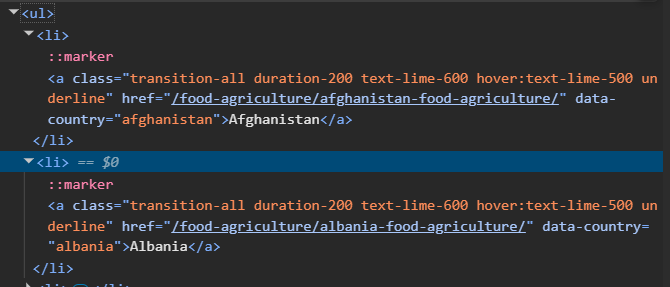

In [6]:
# Base URL
BASE_URL = 'https://www.worldometers.info'

# Get list of countries
countries = []
for a_tag in soup.select('ul li a'):
    country_name = a_tag.text.strip()
    link_ref = a_tag.get('href')  # example: /food-agriculture/afghanistan-food-agriculture/
    full_url = BASE_URL + link_ref  # complete the URL
    countries.append((country_name, full_url))


In [7]:
# Check countries
countries

[('CO2 emissions', 'https://www.worldometers.info/co2-emissions/'),
 ('Coronavirus', 'https://www.worldometers.info/coronavirus'),
 ('Countries',
  'https://www.worldometers.info/geography/countries-of-the-world/'),
 ('Energy', 'https://www.worldometers.info/energy/'),
 ('Flags', 'https://www.worldometers.info/geography/flags-of-the-world/'),
 ('Food & Agriculture', 'https://www.worldometers.info/food-agriculture/'),
 ('GDP by country', 'https://www.worldometers.info/gdp/gdp-by-country/'),
 ('Water', 'https://www.worldometers.info/water/'),
 ('World Map', 'https://www.worldometers.info/world-map/'),
 ('Population', 'https://www.worldometers.info/population/'),
 ('CO2 emissions', 'https://www.worldometers.info/co2-emissions/'),
 ('Coronavirus', 'https://www.worldometers.info/coronavirus'),
 ('Countries',
  'https://www.worldometers.info/geography/countries-of-the-world/'),
 ('Energy', 'https://www.worldometers.info/energy/'),
 ('Flags', 'https://www.worldometers.info/geography/flags-of-

In [8]:
# Keep only https://www.worldometers.info/food-agriculture/xxxx
countries = [country for country in countries if '/food-agriculture/' in country[1]]
# Lihat hasil countries
countries[:5]  # Show first 5 countries

[('Food & Agriculture', 'https://www.worldometers.info/food-agriculture/'),
 ('Food & Agriculture', 'https://www.worldometers.info/food-agriculture/'),
 ('Afghanistan',
  'https://www.worldometers.info/food-agriculture/afghanistan-food-agriculture/'),
 ('Albania',
  'https://www.worldometers.info/food-agriculture/albania-food-agriculture/'),
 ('Algeria',
  'https://www.worldometers.info/food-agriculture/algeria-food-agriculture/')]

In [9]:
# Delete the 2 first elements
countries = countries[2:]
# Lihat hasil countries
countries[:5]  # Show first 5 countries

[('Afghanistan',
  'https://www.worldometers.info/food-agriculture/afghanistan-food-agriculture/'),
 ('Albania',
  'https://www.worldometers.info/food-agriculture/albania-food-agriculture/'),
 ('Algeria',
  'https://www.worldometers.info/food-agriculture/algeria-food-agriculture/'),
 ('American Samoa',
  'https://www.worldometers.info/food-agriculture/american-samoa-food-agriculture/'),
 ('Andorra',
  'https://www.worldometers.info/food-agriculture/andorra-food-agriculture/')]

# Scrape Information

## Go to each link

In [10]:
def get_country_soup(country_url):
    response = requests.get(country_url)
    return BeautifulSoup(response.text, 'html.parser')

## Scrape all data

In [11]:
def scrape_country_data(country_name, country_url):
    try:
        country_soup = get_country_soup(country_url)

        # --------- Find Undernourished Section ----------
        undernourished = None
        undernourished_pct = None
        share_global_undernourished = None
        undernourishment_rank = None
        
        h2_undernourished = country_soup.find('h2', id='undernourished')
        if h2_undernourished:
            next_elements = h2_undernourished.find_all_next()
            
            found_text_2xl = False
            found_text_xl_count = 0

            for elem in next_elements:
                if elem.name == 'strong':
                    classes = elem.get('class', [])
                    if 'text-2xl' in classes and not found_text_2xl:
                        undernourished = elem.text.strip()
                        found_text_2xl = True
                    elif 'text-xl' in classes:
                        if found_text_xl_count == 0:
                            undernourished_pct = elem.text.strip()
                        elif found_text_xl_count == 1:
                            share_global_undernourished = elem.text.strip()
                        found_text_xl_count += 1

                elif elem.name == 'a':
                    classes = elem.get('class', [])
                    if 'font-bold!' in classes and 'text-xl' in classes:
                        undernourishment_rank = elem.text.strip()

        # --------- Find Forest Area Section ----------
        forest_area = None
        share_world_forests = None

        h2_forest = country_soup.find('h2', id='forest')
        if h2_forest:
            next_elements_forest = h2_forest.find_all_next()
            
            found_forest_area = False

            for elem in next_elements_forest:
                if elem.name == 'strong':
                    classes = elem.get('class', [])
                    if 'text-2xl' in classes and not found_forest_area:
                        forest_area = elem.text.strip()
                        found_forest_area = True
                    elif 'text-xl' in classes and share_world_forests is None:
                        share_world_forests = elem.text.strip()
                        break  # sudah dapat keduanya

        # --------- Find Cropland Section ----------
        cropland = None
        share_world_croplands = None

        h2_cropland = country_soup.find('h2', id='cropland')
        if h2_cropland:
            next_elements_cropland = h2_cropland.find_all_next()

            found_cropland_area = False

            for elem in next_elements_cropland:
                if elem.name == 'strong':
                    classes = elem.get('class', [])
                    if 'text-2xl' in classes and not found_cropland_area:
                        cropland = elem.text.strip()
                        found_cropland_area = True
                    elif 'text-xl' in classes and share_world_croplands is None:
                        share_world_croplands = elem.text.strip()
                        break

        return {
            'Country': country_name,
            'Undernourished': undernourished,
            'Undernourished %': undernourished_pct,
            'Undernourishment Rank': undernourishment_rank,
            'Share of Global Undernourished': share_global_undernourished,
            'Forest Area': forest_area,
            'Share of World Forests': share_world_forests,
            'Cropland': cropland,
            'Share of World Croplands': share_world_croplands
        }
        
    except Exception as e:
        print(f"Failed to scrape {country_name}: {e}")
        return None


In [12]:
# Scrape data for all countries
import time
DELAY_SECONDS = 2  # delay between requests to avoid overloading the server
all_data = []

for country_name, country_url in countries:
    print(f"Scraping {country_name}...")
    data = scrape_country_data(country_name, country_url)
    if data:
        all_data.append(data)
    time.sleep(DELAY_SECONDS) # add delay

print("\nScraping finished!")


Scraping Afghanistan...


Scraping Albania...
Scraping Algeria...
Scraping American Samoa...
Scraping Andorra...
Scraping Angola...
Scraping Anguilla...
Scraping Antigua and Barbuda...
Scraping Argentina...
Scraping Armenia...
Scraping Aruba...
Scraping Australia...
Scraping Austria...
Scraping Azerbaijan...
Scraping Bahamas...
Scraping Bahrain...
Scraping Bangladesh...
Scraping Barbados...
Scraping Belarus...
Scraping Belgium...
Scraping Belize...
Scraping Benin...
Scraping Bermuda...
Scraping Bhutan...
Scraping Bolivia...
Scraping Bosnia and Herzegovina...
Scraping Botswana...
Scraping Brazil...
Scraping British Virgin Islands...
Scraping Brunei...
Scraping Bulgaria...
Scraping Burkina Faso...
Scraping Burundi...
Scraping Cabo Verde...
Scraping Cambodia...
Scraping Cameroon...
Scraping Canada...
Scraping Cayman Islands...
Scraping Central African Republic...
Scraping Chad...
Scraping Chile...
Scraping China...
Scraping Colombia...
Scraping Comoros...
Scraping Congo...
Scraping Cook Islands...
Scraping Costa R

In [13]:
# # Simpan ke file
df = pd.DataFrame(all_data)
df

,Country,Undernourished,Undernourished %,Undernourishment Rank,Share of Global Undernourished,Forest Area,Share of World Forests,Cropland,Share of World Croplands
0,Afghanistan,"10,600,000",28.85%,#39,1.41%,"1,350,000",0.034%,"7,910,000",0.51%
1,Albania,"200,000",6.91%,#94,0.027%,"769,580",0.019%,"691,100",0.044%
2,Algeria,"1,600,000",3.76%,#48,0.21%,"1,971,200",0.049%,"8,483,430",0.54%
3,American Samoa,None,None,None,None,"17,460",0.00044%,"4,900",0.00031%
4,Andorra,None,None,None,None,"16,000",0.00040%,820,0.000053%
...,...,...,...,...,...,...,...,...,...
217,Wallis & Futuna,None,None,None,None,"5,830",0.00015%,"6,000",0.00038%
218,Western Sahara,None,None,None,None,"707,000",0.018%,"4,000",0.00026%
219,Yemen,"11,000,000",32.27%,#121,1.46%,"549,000",0.014%,"1,387,700",0.089%
220,Zambia,"8,000,000",44.51%,#105,1.06%,"48,301,800",1.21%,"3,836,000",0.25%


In [14]:
# Rename columns
df.columns = [
    'Country',
    'Undernourished',
    'Undernourished_pct',
    'Undernourishment_Rank',
    'Share_of_Global_Undernourished',
    'Forest_Area',
    'Share_of_World_Forests',
    'Cropland',
    'Share_of_World_Croplands'
]

# Cleaning the data
# Replace , with empty string and convert to numeric
df['Undernourished'] = df['Undernourished'].str.replace(',', '').astype(float)
df['Undernourished_pct'] = df['Undernourished_pct'].str.replace('%', '').str.replace(',', '').astype(float) / 100
df['Undernourishment_Rank'] = df['Undernourishment_Rank'].str.replace('#', '').astype(float)
df['Share_of_Global_Undernourished'] = df['Share_of_Global_Undernourished'].str.replace('%', '').str.replace(',', '').astype(float) / 100
df['Forest_Area'] = df['Forest_Area'].str.replace(',', '').astype(float)
df['Share_of_World_Forests'] = df['Share_of_World_Forests'].str.replace('%', '').str.replace(',', '').astype(float) / 100
df['Cropland'] = df['Cropland'].str.replace(',', '').astype(float)
df['Share_of_World_Croplands'] = df['Share_of_World_Croplands'].str.replace('%', '').str.replace(',', '').astype(float) / 100
df

,Country,Undernourished,Undernourished_pct,Undernourishment_Rank,Share_of_Global_Undernourished,Forest_Area,Share_of_World_Forests,Cropland,Share_of_World_Croplands
0,Afghanistan,10600000.0,0.2885,39.0,0.01410,1350000.0,0.000340,7910000.0,5.100000e-03
1,Albania,200000.0,0.0691,94.0,0.00027,769580.0,0.000190,691100.0,4.400000e-04
2,Algeria,1600000.0,0.0376,48.0,0.00210,1971200.0,0.000490,8483430.0,5.400000e-03
3,American Samoa,NaN,NaN,NaN,NaN,17460.0,0.000004,4900.0,3.100000e-06
4,Andorra,NaN,NaN,NaN,NaN,16000.0,0.000004,820.0,5.300000e-07
...,...,...,...,...,...,...,...,...,...
217,Wallis & Futuna,NaN,NaN,NaN,NaN,5830.0,0.000001,6000.0,3.800000e-06
218,Western Sahara,NaN,NaN,NaN,NaN,707000.0,0.000180,4000.0,2.600000e-06
219,Yemen,11000000.0,0.3227,121.0,0.01460,549000.0,0.000140,1387700.0,8.900000e-04
220,Zambia,8000000.0,0.4451,105.0,0.01060,48301800.0,0.012100,3836000.0,2.500000e-03
